Internal Test - CPM-Net: 0.841 at FPPI=0.507
Internal Test - nnDet: 0.857 at FPPI=0.500
Internal Test - Deformable: 0.921 at FPPI=0.500
Internal Test - Deformable (DINO): 0.897 at FPPI=0.500
Internal Test - Ours (DINO): 0.865 at FPPI=0.500
Internal Test - Ours (artery-inf. MAE): 0.929 at FPPI=0.500
External Test - CPM-Net: 0.901 at FPPI=0.500
External Test - nnDet: 0.901 at FPPI=0.500
External Test - Deformable: 0.941 at FPPI=0.500
External Test - Deformable (DINO): 0.931 at FPPI=0.500
External Test - Ours (DINO): 0.921 at FPPI=0.500
External Test - Ours (artery-inf. MAE): 0.960 at FPPI=0.500
CMHA - CPM-Net: 0.770 at FPPI=0.500
CMHA - nnDet: 0.860 at FPPI=0.500
CMHA - Deformable: 0.870 at FPPI=0.500
CMHA - Deformable (DINO): 0.690 at FPPI=0.500
CMHA - Ours (DINO): 0.580 at FPPI=0.500
CMHA - Ours (artery-inf. MAE): 0.920 at FPPI=0.500
Private - CPM-Net: 0.583 at FPPI=0.500
Private - nnDet: 0.679 at FPPI=0.500
Private - Deformable: 0.717 at FPPI=0.500
Private - Deformable (DINO): 0.604 a

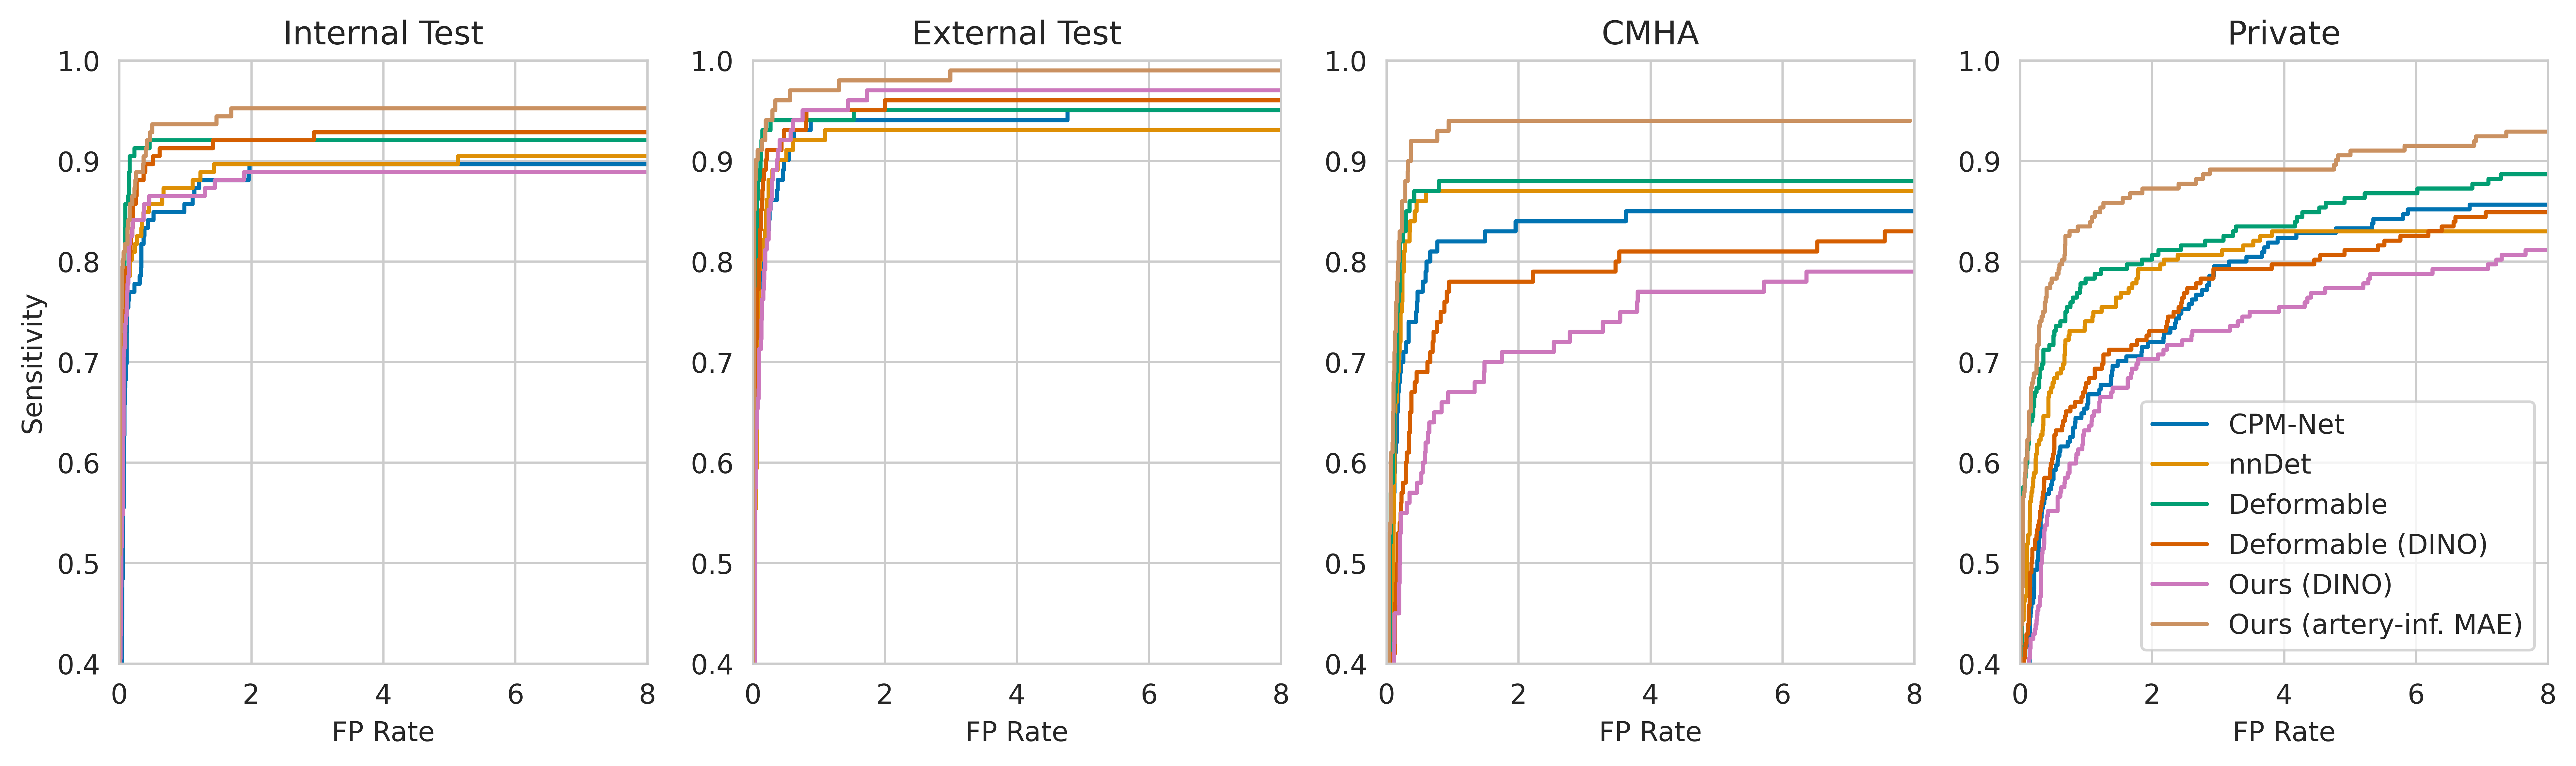

In [ ]:
import matplotlib.pyplot as plt


import numpy as np

import seaborn as sns

sns.set_style("whitegrid")
model_names = [
    "CPM-Net",
    "nnDet",
    "Deformable",
    "Deformable (DINO)",
    "Ours (DINO)",
    "Ours (artery-inf. MAE)",
]

models = [
    "aug_cnn_4l_short/iou0.3_froc_8k",
    "small_feat_aug_cnn_4l_short_input_edt/iou0.3_froc_10k",
    "cnn_4l_input_edt_fp_ogopt/iou0.3_froc_40k",
    "zaug_cnn_4l_short/iou0.3_froc_final",
    "zaug_cnn_4l_short/iou0.3_froc_8k",
    "aug_cnn_4l_short_input_edt_fp_fix/iou0.2_froc_final",
]

model_paths = (
    "/projects/vig/alberto/medical/deform-aneurysm-detection/results/{dataset}/{model}"
)

datasets = ["internal_test", "external", "cmha", "hospital140"]

dataset_names = ["Internal Test", "External Test", "CMHA", "Private"]

# set seaborn color palette
# list some sns palettes

palettes = ["deep", "muted", "bright", "pastel", "dark", "colorblind"]
sns.set_palette("colorblind")

fig, axs = plt.subplots(1, 4, figsize=(16, 4), dpi=600)

for i in range(len(datasets)):
    dataset = datasets[i]
    dataset_name = dataset_names[i]
    for j in range(len(models)):

        model = models[j]
        model_name = model_names[j]
        path = model_paths.format(dataset=dataset, model=model)
        fppi = np.load(path + "/figures/aneurysm_FPpI.npy")
        sens = np.load(path + "/figures/aneurysm_recalls.npy")
        if i == 3 and j == 1:
            sens_len = len(sens)
            thr = 0.83
            sens[sens > thr] = thr
        if i == 3 and j == 0:
            sens = sens + 0.05
        axs[i].plot(fppi, sens, label=model_name)
        # print the value of sens when fppi is 0.5
        print(
            f"{dataset_name} - {model_name}: {sens[np.argmin(np.abs(fppi - 0.5))]:.3f} at FPPI={fppi[np.argmin(np.abs(fppi - 0.5))]:.3f}"
        )
        
    axs[i].set_xlim(0, 8)
    axs[i].set_ylim(0.4, 1)
    axs[i].set_xlabel("FP Rate")
    axs[i].set_title(dataset_name)

axs[0].set_ylabel("Sensitivity")


plt.legend()

# fig with 1 row and 4 columns

# save fig

plt.savefig("froc_comparison.png", bbox_inches="tight", transparent=True)